In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
alarms_df = pd.read_csv('alarms-merged.csv', sep=';')

In [3]:
alarms_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76232 entries, 0 to 76231
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               76232 non-null  int64
 1   merged_id        76232 non-null  str  
 2   region_id        76232 non-null  int64
 3   region_title     76232 non-null  str  
 4   region_city      76232 non-null  str  
 5   all_region       76232 non-null  int64
 6   start            76232 non-null  str  
 7   end              76232 non-null  str  
 8   original_alarms  76232 non-null  str  
dtypes: int64(3), str(6)
memory usage: 5.2 MB


In [4]:
alarms_df.head(5)

,id,merged_id,region_id,region_title,region_city,all_region,start,end,original_alarms
0,35427,8a51c79fd40b6fc9be68e7aa3601e602,12,Львівська область,Львівська обл.,1,2022-02-24 07:43:17,2022-02-24 09:52:28,"[""52432""]"
1,71822,a6fa45504565dc0928efc8807db66487,23,Чернігівська область,Чернігівська обл.,1,2022-02-24 14:00:43,2022-02-24 17:11:43,"[""53292""]"
2,1746,c0ff722f9fac93e89919c7b09695dda5,3,Вінницька область,Вінницька обл.,1,2022-02-24 15:40:42,2022-02-24 16:10:42,"[""52080""]"
3,55540,066e25a0712b306a9b95230f6ec4a051,19,Харківська область,Харківська обл.,1,2022-02-24 20:11:47,2022-02-24 20:59:47,"[""52857""]"
4,54611,73dcb24720672b203e7c6763639860f3,18,Тернопільська область,Тернопільська обл.,1,2022-02-25 01:59:36,2022-02-25 09:00:19,"[""52700""]"


In [5]:
alarms_df['start'] = pd.to_datetime(alarms_df['start'])
alarms_df['end'] = pd.to_datetime(alarms_df['end'])

In [6]:
alarms_df.isnull().sum()

id                 0
merged_id          0
region_id          0
region_title       0
region_city        0
all_region         0
start              0
end                0
original_alarms    0
dtype: int64

In [7]:
alarms_df['duration_minutes'] = (alarms_df['end'] - alarms_df['start']).dt.total_seconds() / 60

In [8]:
alarms_df['hour'] = alarms_df['start'].dt.hour
alarms_df['month'] = alarms_df['start'].dt.month
alarms_df['day_of_week'] = alarms_df['start'].dt.day_name()

In [9]:
alarms_df = alarms_df[(alarms_df['duration_minutes'] > 0) & (alarms_df['duration_minutes'] <= 2880)]

### Visualisations

In [10]:
sns.set_theme(style="whitegrid", font_scale=1.3)

#### Viz 1: Total Alarms by Region

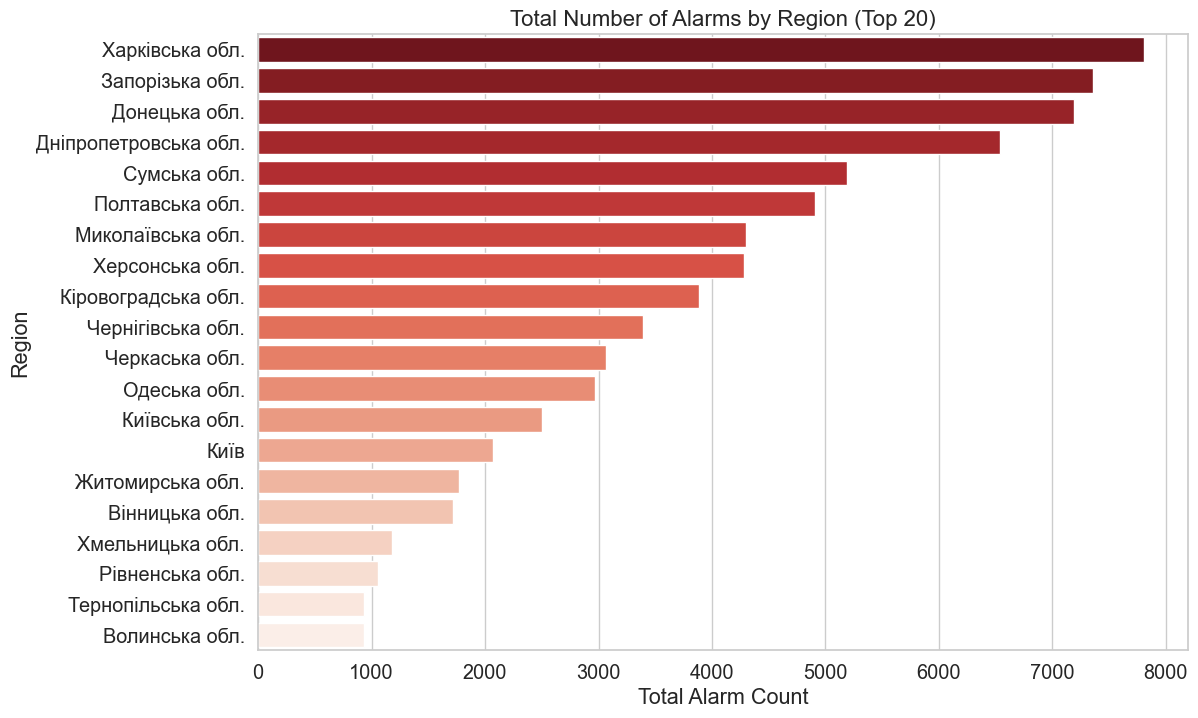

In [11]:
plt.figure(figsize=(12, 8))
region_counts = alarms_df['region_city'].value_counts().head(20)
sns.barplot(y=region_counts.index, x=region_counts.values, palette='Reds_r', hue=region_counts.index, legend=False)
plt.title('Total Number of Alarms by Region (Top 20)', fontsize=16)
plt.xlabel('Total Alarm Count')
plt.ylabel('Region')
plt.show()

#### Viz 2: Distribution of Alarm Durations

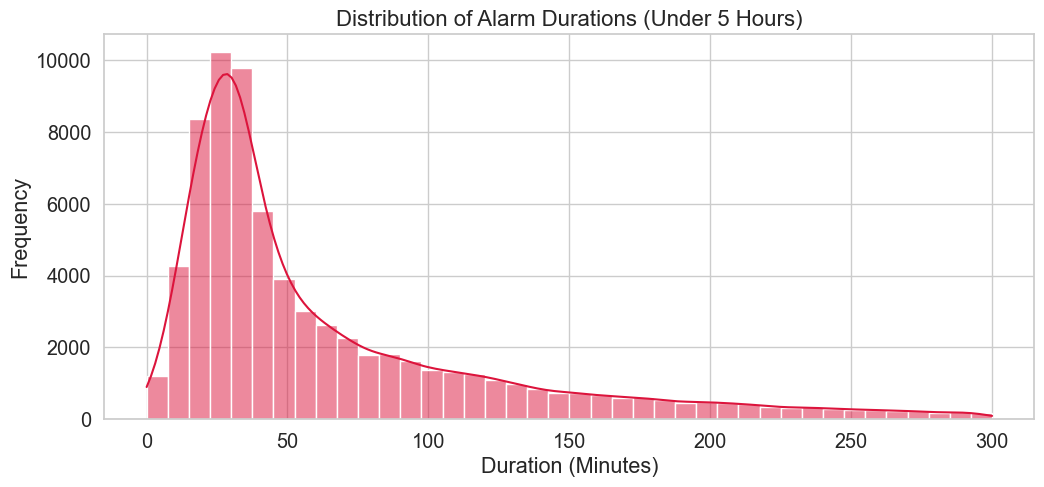

In [12]:
plt.figure(figsize=(12, 5))
# Filtering to durations under 5 hours (300 mins) for a cleaner histogram view
sns.histplot(alarms_df[alarms_df['duration_minutes'] <= 300]['duration_minutes'], bins=40, kde=True, color='crimson')
plt.title('Distribution of Alarm Durations (Under 5 Hours)', fontsize=16)
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

#### Viz 3: Alarms by Hour of the Day

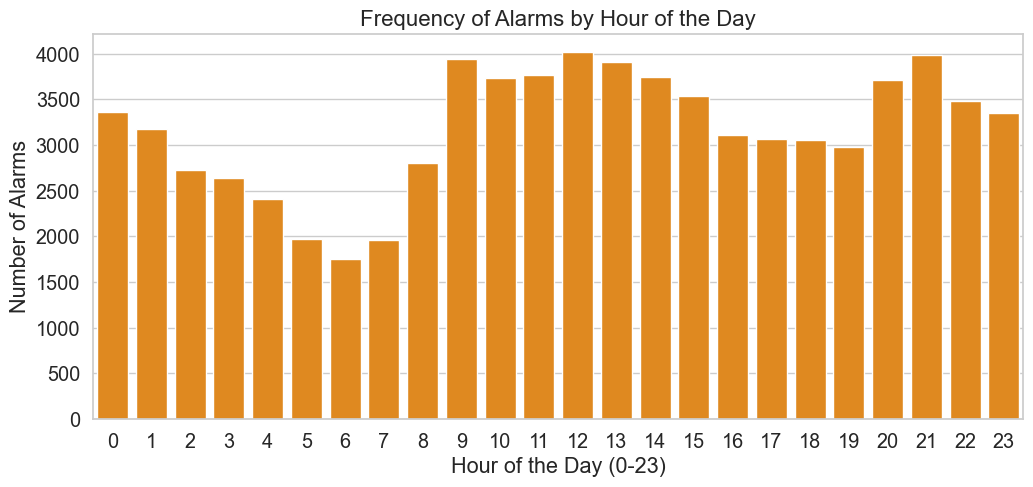

In [13]:
plt.figure(figsize=(12, 5))
sns.countplot(data=alarms_df, x='hour', color='darkorange')
plt.title('Frequency of Alarms by Hour of the Day', fontsize=16)
plt.xlabel('Hour of the Day (0-23)')
plt.ylabel('Number of Alarms')
plt.show()

#### Viz 4: Alarms by Day of the Week

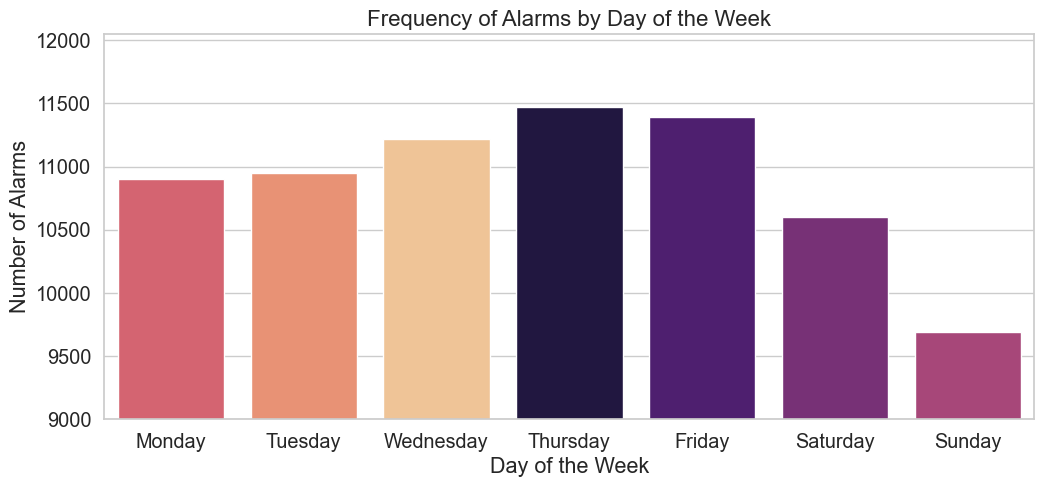

In [16]:
plt.figure(figsize=(12, 5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ax = sns.countplot(data=alarms_df, x='day_of_week', order=days_order, palette='magma', hue='day_of_week', legend=False)
ax.set_ylim(bottom=9000)
plt.title('Frequency of Alarms by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Number of Alarms')
plt.show()

#### Viz 5: Average Alarm Duration by Region

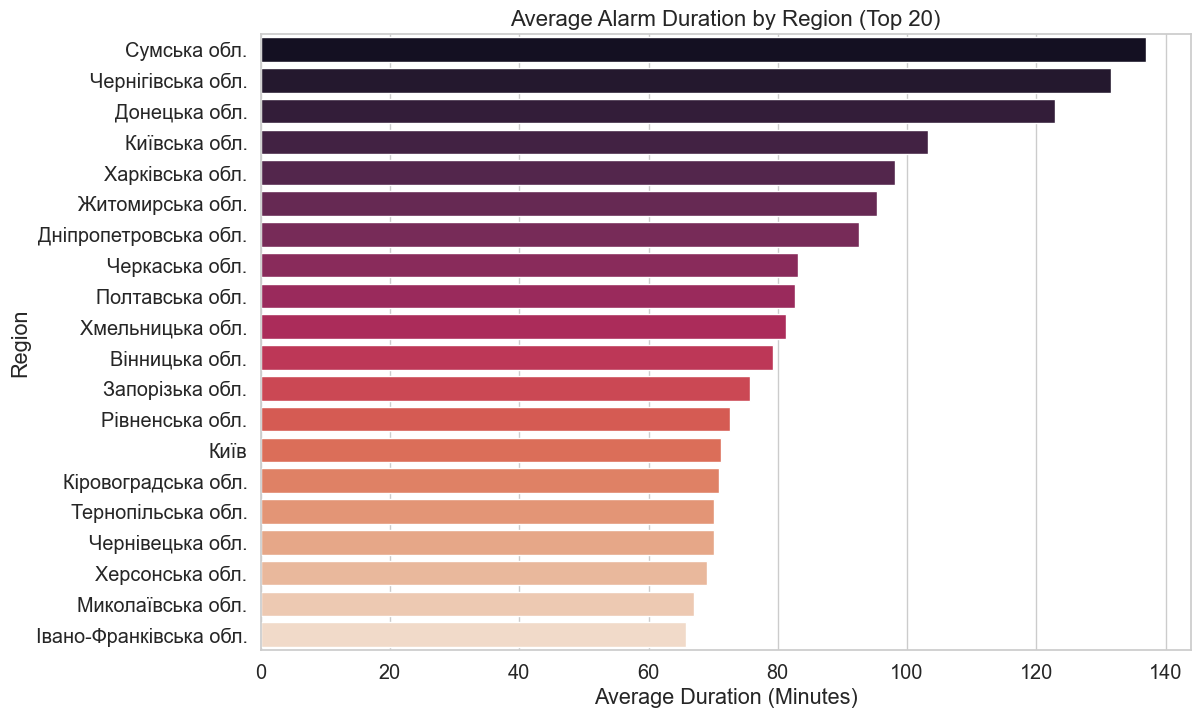

In [15]:
plt.figure(figsize=(12, 8))
avg_duration = alarms_df.groupby('region_city')['duration_minutes'].mean().sort_values(ascending=False).head(20)
sns.barplot(x=avg_duration.values, y=avg_duration.index, palette='rocket', hue=avg_duration.index, legend=False)
plt.title('Average Alarm Duration by Region (Top 20)', fontsize=16)
plt.xlabel('Average Duration (Minutes)')
plt.ylabel('Region')
plt.show()